# Week 12 - Observation-conditioned reconstruction of DSMC moments
<!-- MIE690A article-aligned validation v4 -->
Research source: Ehsan Roohi, *Geometry-native machine learning reconstruction
of DSMC moment fields with support monitoring*, 2026,
[arXiv:2609.01637](https://doi.org/10.48550/arXiv.2609.01637).
Submitted to JCP according to the author; not described here as a published JCP article.

**Scope:** an original CPU teaching analog, not MambaIR training or reproduction
of the paper's nine-field cylinder estimator. Synthetic Gaussian blocks are
NOT DSMC simulations and are deliberately labelled as such. The particle
exercise checks moment algebra; the field exercise checks reconstruction logic.
Prerequisites: Weeks 3, 4, 10; allow 90 minutes. Restart and Run All.
No research checkpoint, raw archive or retained results file is modified.

Predict: can a perfectly smooth heat-flux field have the correct energy
residual and still be wrong? Can a historical prior replace the measured mean?

**Development extension:** this checkout trains a fresh Noise2Noise-style MLP on real DSMC data. Until merged, use this local branch; the main-branch Colab button below opens the previously published version.

**Research extension:** the final section reads real author-research evidence, clearly separated from the synthetic warm-up.
<!-- FLOWMLLAB_COLAB_LAUNCH_V1 -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week12/W12_DSMC_Moment_Reconstruction.ipynb)


In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1
# In Colab this cell obtains the complete repository and installs the tested package.
# In a local checkout it leaves the active environment and working directory unchanged.
from pathlib import Path as _FlowMLLabPath
import os as _flowmllab_os
import subprocess as _flowmllab_subprocess
import sys as _flowmllab_sys

if "google.colab" in _flowmllab_sys.modules or _flowmllab_os.environ.get("COLAB_RELEASE_TAG"):
    _flowmllab_root = _FlowMLLabPath("/content/FlowMLLab")
    if not (_flowmllab_root / ".git").is_dir():
        _flowmllab_subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(_flowmllab_root),
            ],
            check=True,
        )
    _flowmllab_subprocess.run(
        [
            _flowmllab_sys.executable, "-m", "pip", "install", "-q", "-e",
            f"{_flowmllab_root}[test]",
        ],
        check=True,
    )
    _flowmllab_notebook_dir = _flowmllab_root / "notebooks/week12"
    _flowmllab_os.chdir(_flowmllab_notebook_dir)
    for _flowmllab_path in (_flowmllab_root, _flowmllab_notebook_dir):
        if str(_flowmllab_path) not in _flowmllab_sys.path:
            _flowmllab_sys.path.insert(0, str(_flowmllab_path))
    print("FlowMLLab ready:", _flowmllab_root)

from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "flowmllab" / "feature_reconstruction.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from flowmllab.feature_reconstruction import *
plt.rcParams.update({'figure.dpi': 125, 'font.size': 10})
print('Original CPU teaching analog; no research checkpoint or CFD/DSMC run.')

Original CPU teaching analog; no research checkpoint or CFD/DSMC run.


## 1. Pool additive statistics before centralising
For unit-weight particles store count $C_0$, first moment $C_i$, second
moment $C_{ij}$, squared-speed sum $E_2$ and energy-flux sum $F_i$.
After pooling, $u_i=C_i/C_0$ and
$J_i=F_i-u_iE_2-2\sum_j C_{ij}u_j+2C_0u_i|u|^2$.
Physical heat flux also requires mass, cell volume and sampling-time factors.
The next example uses unequal blocks and different means to make the
non-commutation visible. It does not model a DSMC collision process.

In [2]:
rng = np.random.default_rng(12)
blocks_v = [rng.normal(size=(300, 3))+[2,0,0], rng.normal(size=(190, 3))+[-1,1,0]]
raw = [additive_moments(v) for v in blocks_v]
pooled = {k: sum(r[k] for r in raw) for k in raw[0]}
all_v = np.concatenate(blocks_v)
c = all_v-all_v.mean(axis=0)
direct = (np.sum(c*c, axis=1)[:,None]*c).sum(axis=0)
correct = central_heat_numerator(pooled)
wrong = sum(central_heat_numerator(r) for r in raw)
np.testing.assert_allclose(correct, direct, atol=1e-9)
display(pd.DataFrame({'pooled': correct, 'separately centralised': wrong}, index=['x','y','z']))

,pooled,separately centralised
x,-790.810710,-14.093517
y,410.168779,49.898985
z,21.718777,23.504161


## 2. Freeze independent development, validation and test units
Each case has a known analytic scalar pattern, ten noisy observation blocks,
and a separate noisy 80-block-equivalent reference. A shared reference is used
for every method in a case. Raw(3) is a subset of Raw(10), reflecting nested
sampling budgets; neither overlaps the reference. Gaussian independent blocks
cannot establish how a real correlated DSMC sampler behaves.

In [3]:
development = [sampling_case(i) for i in range(100,108)]
validation = [sampling_case(i) for i in range(200,204)]
tests = [sampling_case(i) for i in range(300,306)]
prior, gain = fit_spectral_prior(development, budget=3)
assert gain.min() >= 0 and gain.max() <= 1 and gain[0,0] == 1
print('Prior and gains fitted on development only; frozen before test.')

Prior and gains fitted on development only; frozen before test.


## 3. Prior + bounded observation residual
In an orthonormal DCT, $\hat z=z_{prior}+G(z_{obs}-z_{prior})$, with
$0\leq G\leq1$. This lab estimates a mean prior and signal/noise powers from
development cases. It is NOT the article's trained MambaIR prior or its
cylinder two-component transfer matrices. Set $G_{00}=1$ and restore the
measured mean. Preserving the mean does not make the noisy mean exact.
Compare Raw(3), Raw(10), a Gaussian filter, prior-only, and corrected prior.
Filter width is selected on validation only; no winner is assumed.

In [4]:
from scipy.ndimage import gaussian_filter
widths = [.5, 1., 1.5, 2.]
width = min(widths, key=lambda s: np.mean([nrmse(
    gaussian_filter(c['blocks'][:3].mean(axis=0), s, mode='reflect'),
    c['reference']) for c in validation]))
def estimates(case):
    observation = case['blocks'][:3].mean(axis=0)
    return {'Raw(3)': observation, 'Raw(10)': case['blocks'].mean(axis=0),
            'Gaussian': gaussian_filter(observation, width, mode='reflect'),
            'Prior only': prior, 'Prior + observation': reconstruct(observation, prior, gain)}
print('Frozen Gaussian width:', width)

Frozen Gaussian width: 2.0


## 4. Paired errors, gradients and measured zero-frequency content
NRMSE is sqrt(sum(A*(prediction-reference)^2)/sum(A*reference^2)).
This grid has equal cell areas. Spatial cells are not independent replicates.
We show reference-based error and analytic-truth error separately, because an
independent high-budget average still has noise. Gradient error catches a
failure that a smooth-looking contour may hide. All seed-level errors remain.

,seed,method,reference NRMSE,truth NRMSE,gradient NRMSE,observed mean change
0,300,Raw(3),0.952887,0.954246,6.591940,3.295975e-17
1,300,Raw(10),0.533903,0.513973,3.523869,7.425719e-03
2,300,Gaussian,0.246171,0.166949,0.487205,3.295975e-17
3,300,Prior only,0.191349,0.062715,0.424529,-3.042169e-03
4,300,Prior + observation,0.195100,0.075426,0.504199,3.295975e-17
5,301,Raw(3),1.019313,1.020087,6.948055,1.647987e-17
6,301,Raw(10),0.577178,0.555633,3.861567,-1.748677e-03
7,301,Gaussian,0.263206,0.166953,0.519754,-8.673617e-18
8,301,Prior only,0.235950,0.120281,0.474516,-6.295813e-03
9,301,Prior + observation,0.221957,0.093352,0.549219,9.020562e-17


,reference NRMSE,truth NRMSE,gradient NRMSE,observed mean change
method,,,,
Gaussian,0.250236,0.166592,0.505848,8.095376e-18
Prior + observation,0.207905,0.089127,0.518559,-1.619075e-17
Prior only,0.214012,0.097029,0.449885,-3.545409e-03
Raw(10),0.552596,0.531144,3.664192,-2.319055e-03
Raw(3),0.975413,0.975804,6.669419,-4.192248e-18


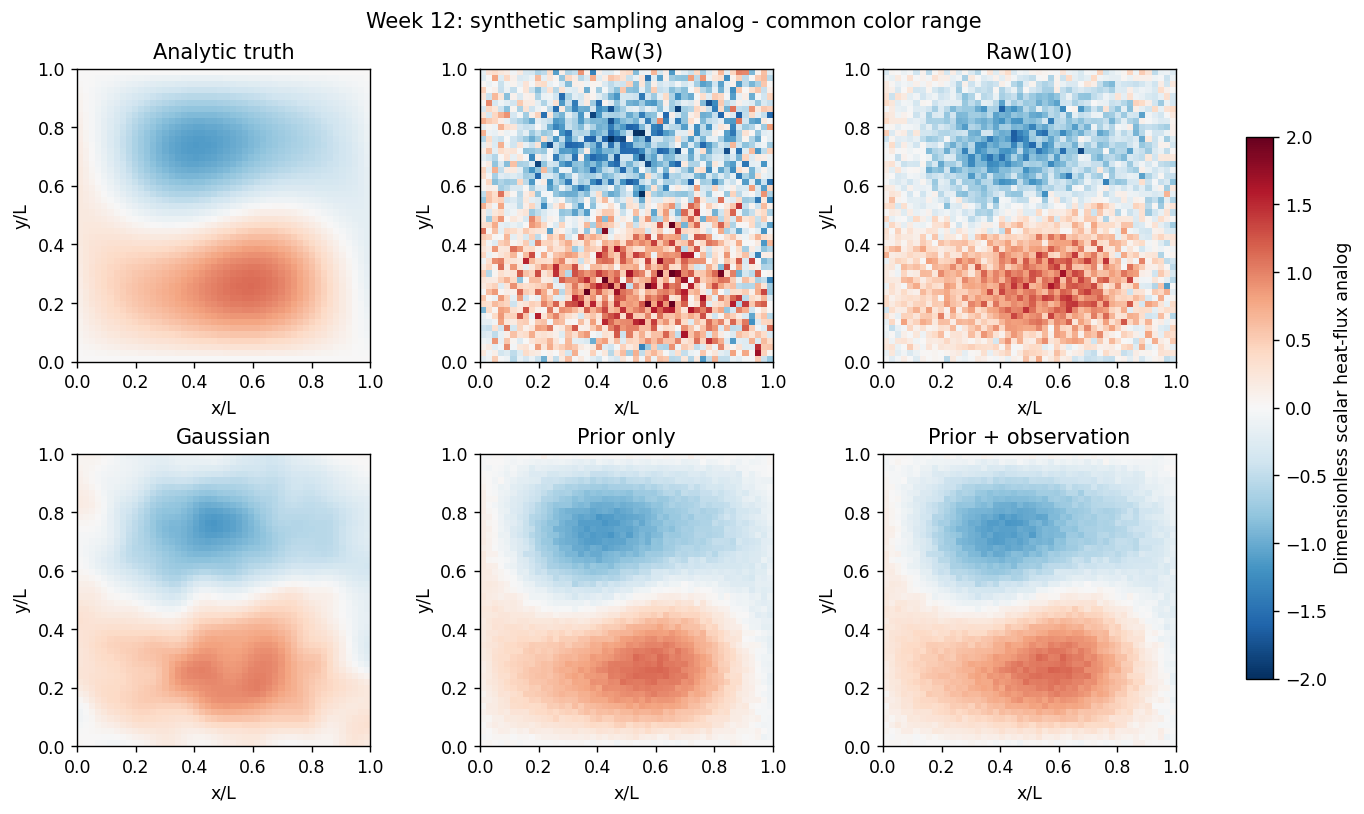

Values outside display range, by method: {'Analytic truth': 0, 'Raw(3)': 10, 'Raw(10)': 0, 'Gaussian': 0, 'Prior only': 0, 'Prior + observation': 0}


In [5]:
rows = []
for seed, case in enumerate(tests, start=300):
    for name, field in estimates(case).items():
        grad = np.stack(np.gradient(field, case['x'][1]-case['x'][0]))
        true_grad = np.stack(np.gradient(case['truth'], case['x'][1]-case['x'][0]))
        rows.append({'seed': seed, 'method': name,
            'reference NRMSE': nrmse(field, case['reference']),
            'truth NRMSE': nrmse(field, case['truth']),
            'gradient NRMSE': nrmse(grad, true_grad),
            'observed mean change': field.mean()-case['blocks'][:3].mean()})
metrics = pd.DataFrame(rows)
display(metrics)
display(metrics.groupby('method').mean(numeric_only=True).drop(columns='seed'))
corrected = metrics[metrics['method']=='Prior + observation']
assert corrected['observed mean change'].abs().max() < 1e-12
case = tests[0]
fields = {'Analytic truth': case['truth'], **estimates(case)}
fig, axes = plt.subplots(2,3,figsize=(11,6.4),layout='constrained')
for ax, (name, field) in zip(axes.flat, fields.items()):
    image = ax.imshow(field, origin='lower', extent=[0,1,0,1], cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set(title=name, xlabel='x/L', ylabel='y/L')
fig.colorbar(image, ax=axes, shrink=.8, label='Dimensionless scalar heat-flux analog')
fig.suptitle('Week 12: synthetic sampling analog - common color range')
plt.show()
print('Values outside display range, by method:',
      {k: int(np.count_nonzero(abs(v)>2)) for k,v in fields.items()})

## 5. Support monitoring without looking at the test reference
A deliberately simple field-level residual/noise score is calibrated by the
maximum validation score, then frozen. A new shifted observation can trigger
abstention. This is not the article's 27 component-zone gain-envelope score
and carries no calibrated coverage guarantee. The fallback is to report the
raw observation and request more sampling or new in-condition development data.
A low score alone does not prove the reconstruction is accurate.

In [6]:
noise_variance = float(np.mean([np.var(c['blocks'],axis=0,ddof=1).mean()/3
                               for c in development]))
score = lambda c: support_score(c['blocks'][:3].mean(axis=0), prior, noise_variance)
threshold = max(score(c) for c in validation)
shifted = sampling_case(900, offset=2.)
display(pd.DataFrame([{'case': name, 'score': score(c), 'threshold': threshold,
                      'decision': 'abstain' if score(c)>threshold else 'within heuristic envelope'}
                     for name,c in [('new in-condition draw',tests[0]),('shifted draw',shifted)]]))
assert score(shifted)>threshold

,case,score,threshold,decision
0,new in-condition draw,1.064760,1.032072,abstain
1,shifted draw,17.587861,1.032072,abstain


## 6. Why energy-residual matching is insufficient
For $\delta q=(\partial_y\psi,-\partial_x\psi)$, divergence is zero.
Adding such a field changes heat flux without changing its divergence.
The next finite-difference check uses commuting derivatives on one grid;
it is an algebraic control, not a boundary-value uniqueness theorem.

In [7]:
x = tests[0]['x']; X,Y = np.meshgrid(x,x); h=x[1]-x[0]
psi = np.sin(np.pi*X)**2*np.sin(np.pi*Y)**2
py,px = np.gradient(psi,h,h)
delta_qx,delta_qy=py,-px
divergence=np.gradient(delta_qx,h,axis=1)+np.gradient(delta_qy,h,axis=0)
print('Maximum divergence:', abs(divergence).max(), 'nonzero flux norm:', np.linalg.norm([delta_qx,delta_qy]))
assert abs(divergence).max()<1e-10

Maximum divergence: 1.0658141036401503e-14 nonzero flux norm: 90.16786823884392


## Research bridge and assignment
The paper retains nine moment fields. Its cavity prior is a trained MambaIR
restoration model. Its cylinder method rotates Cartesian heat flux to normal
and tangential components, uses a geometry-adapted transform and bounded
two-component residual transfer, then restores native-area Cartesian means.
This single-scalar Cartesian lab does not implement that complete estimator.

**Assignment:** (1) Introduce temporal correlation and measure the failure of
the 1/B noise law. (2) Replace the scalar pattern with two heat-flux components
and test normal/tangential rotation and its inverse. (3) Add a narrow layer:
measure peak/width bias as well as NRMSE after filtering. (4) Design an
independent-seed reference and matched-budget comparison for your DSMC case.
(5) Explain why mean preservation is not positivity or full conservation.
Do not force Fourier's law in a rarefied non-equilibrium flow.

[Lecture 12](../../lectures/week12_dsmc_moment_reconstruction.pdf).
Source: [Roohi, arXiv:2609.01637](https://doi.org/10.48550/arXiv.2609.01637).
Original teaching implementation and synthetic observations, AI-assisted
authoring and verification; no unpublished solver or checkpoint redistributed.

## 7. Train a real DSMC denoiser, not a figure viewer
**Question:** can independent noisy observations teach a patch MLP to reduce
sampling noise without using a high-budget reference during training?
These qx/qy fields come from Roohi's existing JCP2 cavity archive associated
with [arXiv:2609.01637](https://doi.org/10.48550/arXiv.2609.01637): Kn=0.085,
lid speed 350 m/s, eight three-block observations on the same 100x100 grid.
No archived neural predictions are inputs or targets of this exercise.

This is **same-condition denoising**, not new-condition generalization or
reproduction of the paper's MambaIR/cylinder estimator. The archive was
already inspected before this teaching split; do not call this a newly blind trial.
Plan 20-30 additional classroom minutes; actual CPU training time is printed.

Method inspiration: Lehtinen et al.,
[Noise2Noise (ICML 2018)](https://arxiv.org/abs/1803.04189).
The implementation here is original; no NVlabs code is incorporated.
For paired observations $Y=f+\epsilon$ and $Y'=f+\epsilon'$, squared-loss
training against $Y'$ has the same population optimum as training against
$f$ if $E[\epsilon'\mid Y,f]=0$. Independent, conditionally zero-mean target
noise is sufficient. Distinct filenames alone do not establish this condition.
Finite-sample central moments can be biased; this lab does not prove their
unbiasedness or recover the exact kinetic solution.

In [8]:
import hashlib, json, time
import flowmllab.noise2noise as nn
data_dir = ROOT / 'data/week12_noise2noise'
n2n_manifest = json.loads((data_dir/'manifest.json').read_text())
for name, expected in n2n_manifest['files'].items():
    assert hashlib.sha256((data_dir/name).read_bytes()).hexdigest() == expected
with np.load(data_dir/'observations.npz', allow_pickle=False) as data_file:
    real_seeds = data_file['seeds'].copy()
    real_observations = data_file['raw3'].astype(np.float64)
groups = nn.split_indices(real_seeds, n2n_manifest['split'])
display(pd.DataFrame({name: pd.Series(real_seeds[ids]) for name,ids in groups.items()}))
print(real_observations.shape, '=(seeds, components, rows, columns)')
print(n2n_manifest['independence'])

,train,validation,test
0,26082101,26082105.0,26082107.0
1,26082102,26082106.0,26082108.0
2,26082103,NaN,NaN
3,26082104,NaN,NaN


(8, 2, 100, 100) =(seeds, components, rows, columns)
Distinct seeds and observation/reference disjointness are documented by the source archive; RNG streams and block ancestry were not re-audited from solver logs.


### 7.1 Freeze whole-seed splits and build independent targets
Training: seeds 26082101-104; validation: 105-106; evaluation: 107-108.
For each training input, average only the OTHER three training seeds to form
its target. Thus the target uses nine observation blocks, disjoint from the
input's three blocks according to the source archive. The four input/target
pairs reuse training seeds; they are not four independent paired experiments.
Validation targets are the other validation seed, never training or test data.

A 5x5 two-component patch supplies 50 inputs to a fixed 64x32 tanh MLP.
No coordinates are supplied. Reflection padding is a numerical assumption,
not a verified physical boundary condition; report edge-band errors separately.
Scales are fitted on training data only. Training uses 3,000 locations per seed,
fixed initialization 12, no random-pixel validation split and at most 160 epochs.
Spatial samples and overlapping patches are not independent statistical units.

In [9]:
train_fields = real_observations[groups['train']]
validation_fields = real_observations[groups['validation']]
noisy_targets = nn.independent_targets(train_fields)
np.testing.assert_allclose(noisy_targets[0], train_fields[1:].mean(axis=0))
fit_started = time.perf_counter()
fitted_n2n = nn.fit_experiment(train_fields, validation_fields)
print('CPU fit seconds:', round(time.perf_counter()-fit_started, 2))
print('MLP iterations:', fitted_n2n['mlp'].model[-1].n_iter_)
print('Last training loss:', fitted_n2n['mlp'].model[-1].loss_)
print('Gaussian width selected without reference:', fitted_n2n['gaussian_width'])
display(pd.DataFrame({'sigma':list(fitted_n2n['gaussian_validation']),
                      'paired noisy validation MSE':list(fitted_n2n['gaussian_validation'].values())}))

CPU fit seconds: 6.76
MLP iterations: 160
Last training loss: 0.00976253135949197
Gaussian width selected without reference: 1.0


C:\Users\roohie\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (160) reached and the optimization hasn't converged yet.
  warnings.warn(


,sigma,paired noisy validation MSE
0,0.5,0.053375
1,1.0,0.047789
2,1.5,0.057740
3,2.0,0.071953


### 7.2 Baselines and sampling budgets
Compare Raw(3), validation-selected Gaussian filtering, a development-fitted
DCT filter, the training mean, the fresh MLP, and that MLP after restoring
the observation mean. The last two are separately reported, not selected by
test error. Mean restoration preserves a measurement, not exact truth.

The spectral baseline estimates $N_k$ from between-seed coefficient variance
and $S_k=\max(\bar z_k^2-N_k/4,0)$ from the four training fields, then uses
$G_k=S_k/(S_k+N_k)$, with $G_{00}=1$. Four fields give a noisy estimate of
spectral power; no benefit is assumed. There is no spectral tuning on the reference.
The training-mean baseline exposes the advantage of knowing the same underlying
flow: it uses 12 development blocks and no current observation. The MLP and
spectral method also have this development information. Raw(10) is an additional
larger-budget comparator, NOT a matched-three-block method.

Now open the independent 260-block reference and Raw(10) arrays for evaluation.
The archive documents disjoint reference seeds and Raw(3)/Raw(10) observations.
We preserve this provenance, but have not independently reconstructed RNG streams.

In [10]:
with np.load(data_dir/'evaluation_only.npz', allow_pickle=False) as eval_file:
    real_reference = eval_file['reference'].copy()
    real_raw10 = eval_file['raw10'].copy()
n2n_rows = []
n2n_predictions = {}
for i in groups['test']:
    estimates_real = nn.predict_experiment(fitted_n2n, real_observations[i])
    estimates_real['Raw(10), larger budget'] = real_raw10[i]
    n2n_predictions[int(real_seeds[i])] = estimates_real
    for method, estimate in estimates_real.items():
        for component, scores_real in zip(['qx','qy'], nn.audit_errors(
                estimate, real_reference, real_observations[i])):
            n2n_rows.append({'seed':int(real_seeds[i]), 'field':component,
                             'method':method, **scores_real})
    projected = estimates_real['MLP + observed mean']
    np.testing.assert_allclose(projected.mean(axis=(-2,-1)),
        real_observations[i].mean(axis=(-2,-1)), rtol=0, atol=1e-12)
n2n_metrics = pd.DataFrame(n2n_rows)
display(n2n_metrics)
display(100*n2n_metrics.groupby(['field','method'])[
    ['reference_nrmse','gradient_nrmse','edge_nrmse']].mean())

,seed,field,method,reference_nrmse,gradient_nrmse,edge_nrmse,observed_mean_change,max_absolute_error
0,26082107,qx,Raw(3),0.118826,0.476855,0.086898,0.000000e+00,0.072099
1,26082107,qy,Raw(3),0.178071,0.853998,0.191370,0.000000e+00,0.040542
2,26082107,qx,Gaussian,0.087476,0.473708,0.097635,1.387779e-17,0.386389
3,26082107,qy,Gaussian,0.082998,0.458571,0.128085,0.000000e+00,0.115029
4,26082107,qx,Spectral,0.071580,0.348209,0.061546,1.387779e-17,0.209634
5,26082107,qy,Spectral,0.080970,0.413716,0.101701,-1.387779e-17,0.119190
6,26082107,qx,Training mean (prior only),0.059772,0.239487,0.044632,-1.579633e-04,0.032140
7,26082107,qy,Training mean (prior only),0.090533,0.434716,0.098116,5.116726e-04,0.022677
8,26082107,qx,Noise2Noise MLP,0.103994,0.428796,0.109555,1.462359e-03,0.431450
9,26082107,qy,Noise2Noise MLP,0.062976,0.301416,0.088945,-1.777192e-04,0.117088


reference_nrmse  gradient_nrmse  edge_nrmse
field method                                                                 
qx    Gaussian                           8.762128       47.734025    9.784935
      MLP + observed mean               10.240112       42.150118   10.926540
      Noise2Noise MLP                   10.374427       42.150118   10.972668
      Raw(10), larger budget             6.555177       26.415502    4.795512
      Raw(3)                            11.868888       48.026171    8.753386
      Spectral                           7.173696       35.475153    6.262059
      Training mean (prior only)         5.977159       23.948729    4.463200
qy    Gaussian                           8.199199       45.436298   12.627528
      MLP + observed mean                6.270633       29.326590    8.793060
      Noise2Noise MLP                    6.308009       29.326590    8.836139
      Raw(10), larger budget             9.874233       47.302454   10.804887
      Raw(3)                            17.603453       84.172210   19.071293
      Spectral                           7.976383       40.687174   10.011902
      Training mean (prior only)         9.053307       43.471620    9.811632

### 7.3 Read the fields and failures
Reference NRMSE uses equal-cell relative L2 error. Gradient errors use the
same array-index finite differences on prediction and reference; their
reference is noisy too. The edge band is the outer 10% of array rows/columns,
not a separately verified physical boundary layer. Mean changes remain in
archive units. Only two evaluation seeds are available: no significance,
calibrated uncertainty or speedup claim is justified.

The first held-out seed is displayed by predeclared order, not by its error.
Shared color limits cover all values; nearest-pixel display retains native
100x100 resolution. The full table retains both seeds, both components and
all baselines, even when a simpler estimator wins.

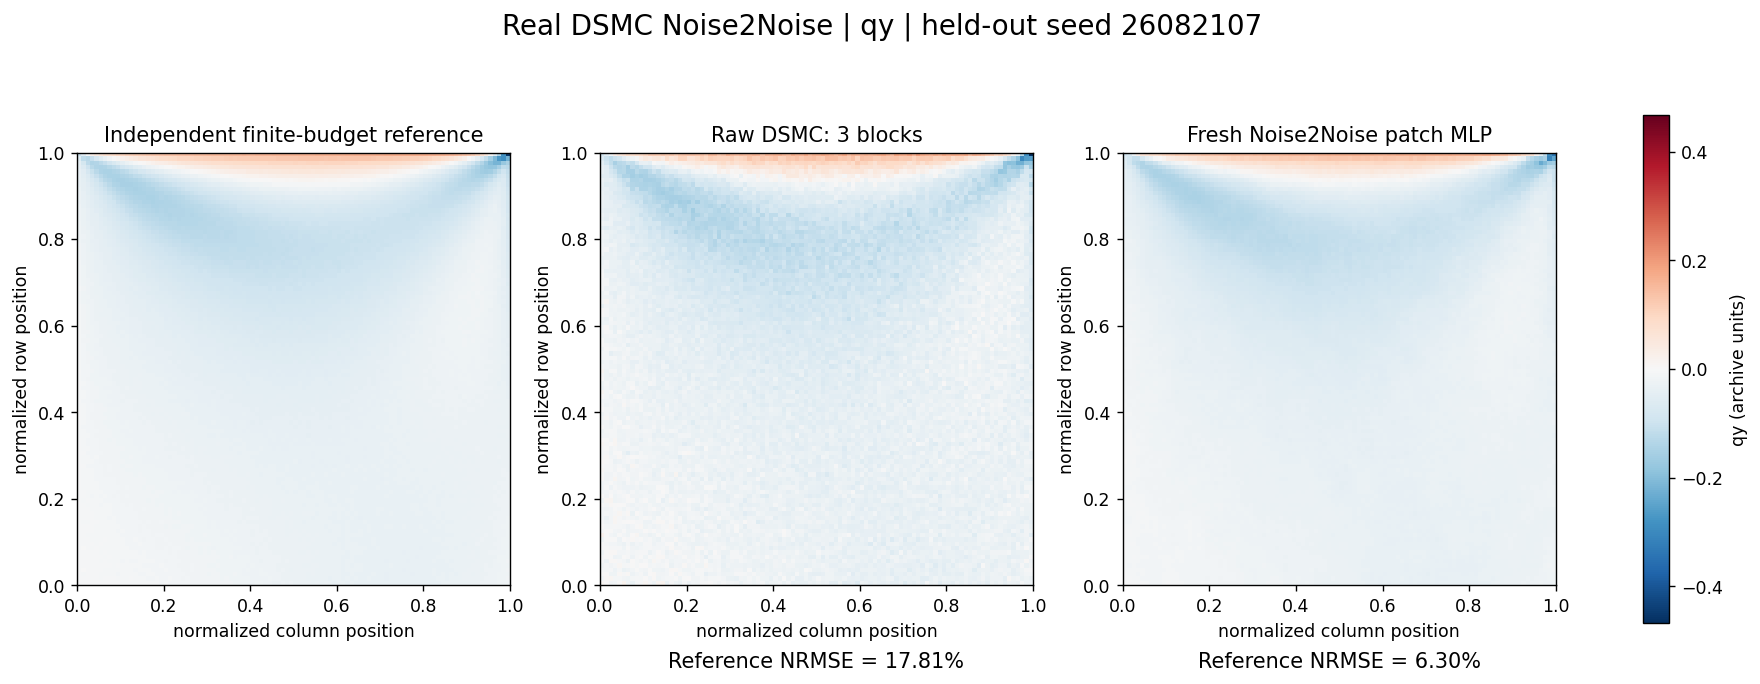

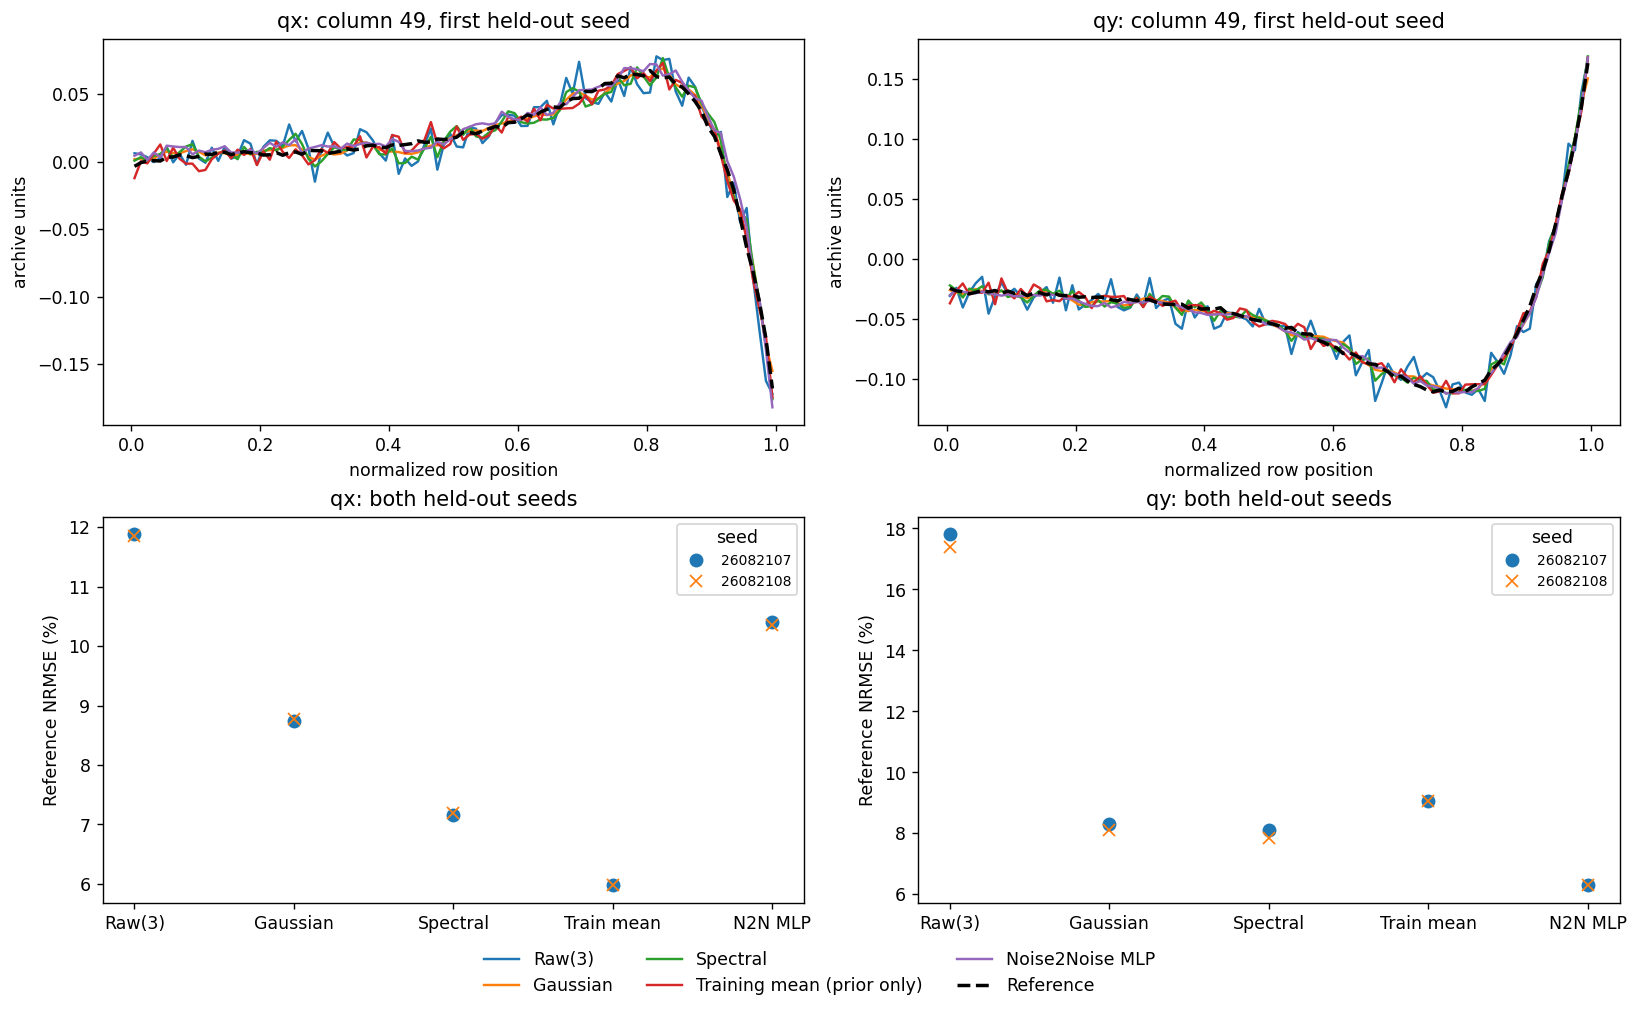

In [11]:
first_test_index = groups['test'][0]
first_test_seed = int(real_seeds[first_test_index])
first_estimates = n2n_predictions[first_test_seed]
nn.contour_figure(real_observations[first_test_index],
    first_estimates['Noise2Noise MLP'], real_reference,
    component='qy', seed=first_test_seed)
plt.show()
nn.diagnostic_figure(first_estimates, real_reference, n2n_rows)
plt.show()

### 7.4 Assignment and qualification gate
1. Explain why using the input seed in its target rewards noise copying.
2. Compare the training mean and MLP: does this dataset demonstrate general
   denoising, or primarily repeated observation of one fixed field?
3. Report whether restoring the observed mean improves or worsens each field.
   Preserve both outcomes and explain why mean preservation need not lower MSE.
4. Explain why correlated overlapping blocks and biased heat-flux estimators
   violate the simplest Noise2Noise assumptions.
5. Before extending to another Kn or lid speed, declare entire-condition
   holdouts and acquire qualified independent realizations. Do not relabel
   these already-inspected seeds as a fresh blind benchmark.

**Deliverable:** seed protocol, loss history summary, all 28 component/method/seed
scores, the two-component profiles, and one paragraph about the strongest
baseline and remaining bias. Do not force neural superiority.
This section trains a new small teaching model from real data on every Run All;
it writes no files. It does not reproduce Roohi's research neural architecture.

## 8. Historical DSMC archive: contrast with the new teaching fit
Source: Roohi, [arXiv:2609.01637](https://doi.org/10.48550/arXiv.2609.01637),
author-supplied JCP2 cavity archive. These DSMC fields predate FlowMLLab.
This historical prospective archive is now inspected evidence, not a new
blind experiment. We retain its method names rather than asserting every
method equals the final manuscript implementation. No neural retraining.
Eight observation seeds; qx and qy; 80 recomputed scores, including a fixed
sigma=1-cell Gaussian comparator (not tuned on these references).
All 64 archived comparison scores agree within 2e-6.
Unlike the synthetic exercise, archived Raw(3) and Raw(10) are disjoint.
The independent finite-budget reference is not exact truth. Errors below
are direct relative L2 errors, not reference-noise-deconvolved scores.
[Complete comparisons, profiles and provenance](../../results/week12_research/README.md).

Historical JCP2 archive re-evaluation; not a new prospective trial or neural training. Archive method names retained; no claim of reproducing the final paper estimator.


mean        min        max
field method                                                  
qx    gaussian_fixed            8.809583   8.747579   8.916751
      pnet_alone                4.904082   4.667326   5.095651
      promoted_full_hierarchy   3.148015   2.886135   3.315285
      raw_b10                   6.573847   6.527396   6.669733
      raw_b3                   11.872931  11.735704  11.934924
qy    gaussian_fixed            8.289059   8.098620   8.445461
      pnet_alone               12.627704  12.256515  12.811569
      promoted_full_hierarchy   4.344967   4.111640   4.498611
      raw_b10                   9.802864   9.704212   9.935331
      raw_b3                   17.610963  17.399228  17.807120

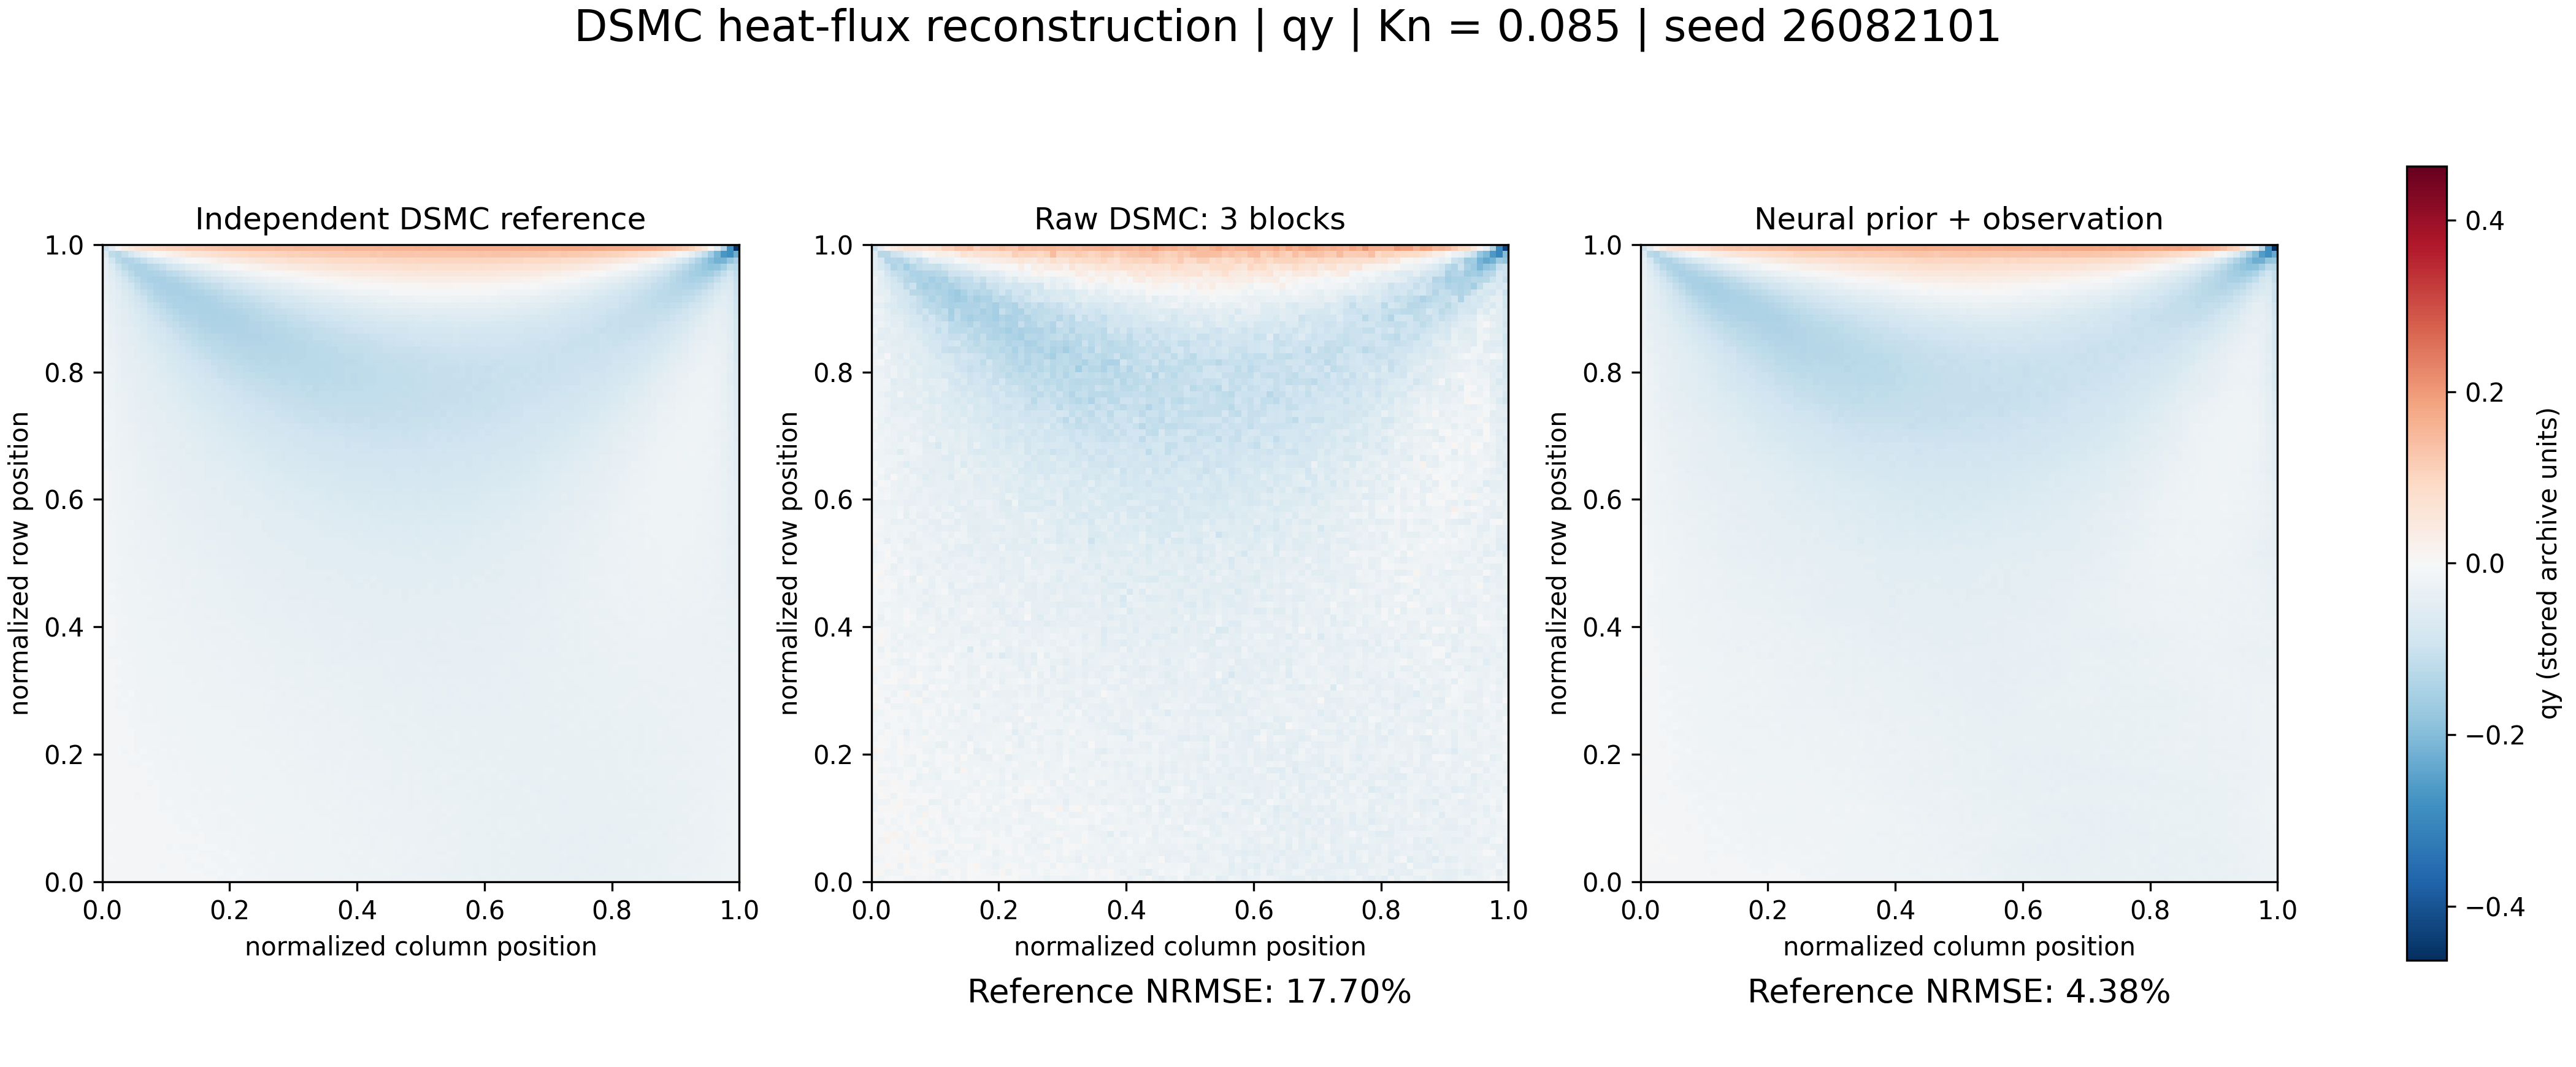

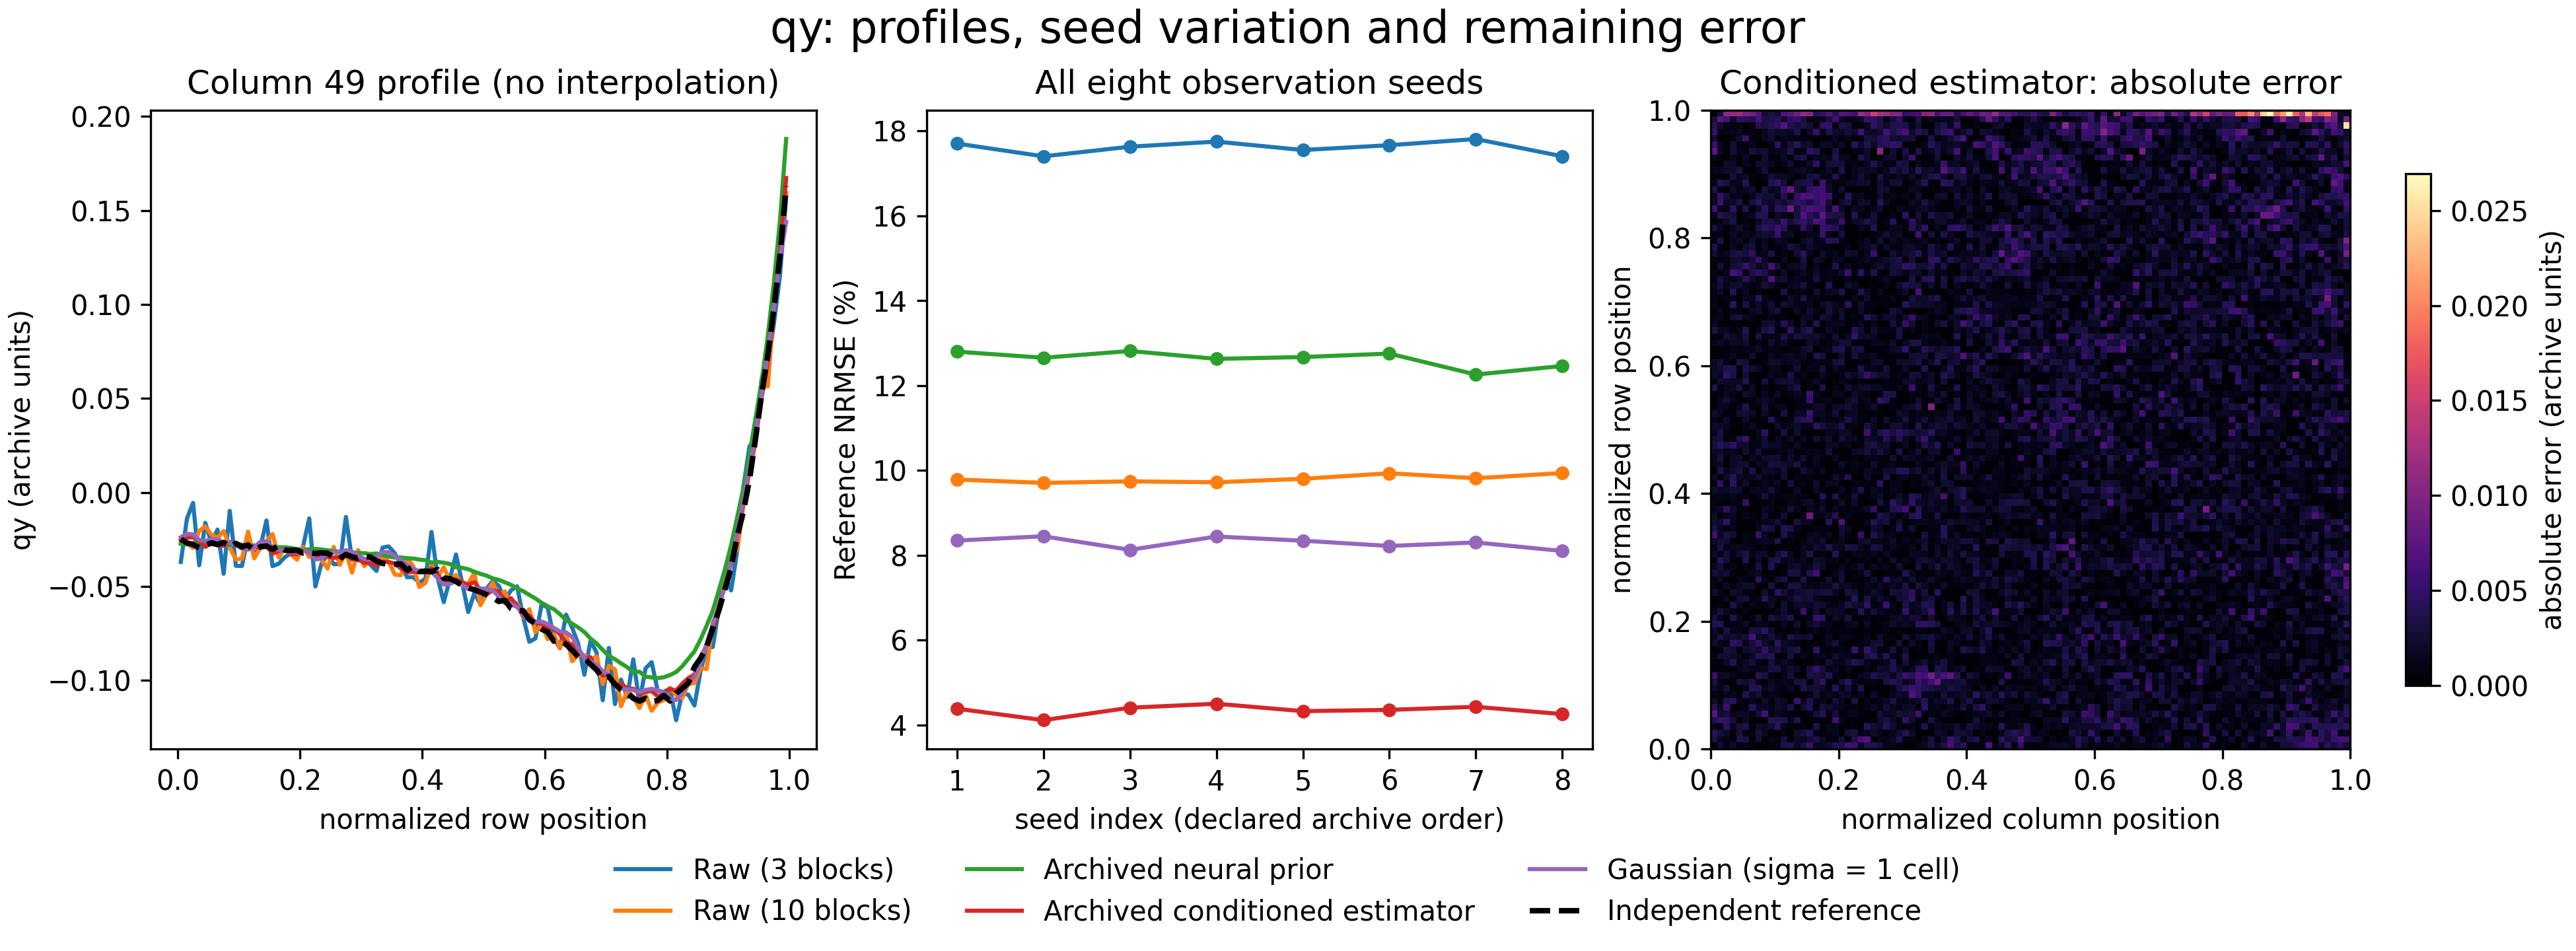

In [12]:
import json, hashlib
evidence = ROOT / 'results' / 'week12_research'
manifest = json.loads((evidence / 'research_manifest.json').read_text())
print(manifest['scope'])

for filename, sha in manifest['files'].items():
    assert hashlib.sha256((evidence / filename).read_bytes()).hexdigest() == sha
real_metrics = pd.read_csv(evidence / 'metrics.csv')
display(100*real_metrics.groupby(['field','method'])['reference_nrmse'].agg(['mean','min','max']))
with np.load(evidence / 'first_seed_fields.npz', allow_pickle=False) as arrays:
    for field in ['qx','qy']:
        reference = arrays[field+'_reference'].astype(float)
        for method in real_metrics.method.unique():
            value = arrays[field+'_'+method].astype(float)
            error = np.linalg.norm(value-reference)/np.linalg.norm(reference)
            saved = real_metrics[(real_metrics.field==field) & (real_metrics.method==method)
                                 & (real_metrics.seed==manifest['illustrated_seed'])].iloc[0]
            np.testing.assert_allclose(error, saved.reference_nrmse, rtol=1e-7)
from IPython.display import Image
display(Image(filename=str(evidence / 'cavity_qy_hero.png'), width=1200))
display(Image(filename=str(evidence / 'cavity_qy_audit.png'), width=1200))

Shared color limits include every displayed value; no interpolation hides
sampling noise. Coordinates are normalized array positions and field units
are the stored archive units. The illustrated seed is the first in the
archive, not the best-scoring one; all eight seed errors are shown.
To repeat the archive audit:
`python qa/build_week12_research_figures.py --archive PATH_TO_JCP2_ZIP --output NEW_SCRATCH`.
The course subset includes only the first seed's displayed fields, the
shared reference and all-seed scores; it is not the complete research data.